# Coffee Shop ETL

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print(f'Seaborn: {sns.__version__}')

Pandas: 2.3.3
Numpy: 2.0.2
Seaborn: 0.13.2


In [3]:
# Import raw csv file for analysis

df = pd.read_csv('raw_coffee_sales.csv')

print('___ Raw Data Sample __')
print(df.head()) 

___ Raw Data Sample __
   OrderID        Date Region            Store Category     Product UnitsSold  \
0     1001  05/01/2026   East  providence cafe   Coffee       Latte        45   
1     1002  2026-05-01   East  Providence Cafe     Food      Muffin        30   
2     1003  2026/05/01   west  Seattle central   Coffee   Cold Brew        52   
3     1004  05-02-2026  South     Austin beans      Tea  Chai Latte        28   
4     1005  2026-05-02   West  Seattle Central     Food       Bagel        40   

   Revenue     Cost  DiscountPercent  
0  $247.50  $135.00              0.0  
1      105       42             10.0  
2  $286.00  $140.00              5.0  
3      126       56              NaN  
4  $140.00   $52.00             15.0  


In [4]:
df.shape

(52, 10)

## Transform Data

In [5]:
# Standardize column names - removes white spaces
df.columns = df.columns.str.strip()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          52 non-null     int64  
 1   Date             52 non-null     object 
 2   Region           51 non-null     object 
 3   Store            52 non-null     object 
 4   Category         52 non-null     object 
 5   Product          52 non-null     object 
 6   UnitsSold        52 non-null     object 
 7   Revenue          52 non-null     object 
 8   Cost             52 non-null     object 
 9   DiscountPercent  50 non-null     float64
dtypes: float64(1), int64(1), object(8)
memory usage: 4.2+ KB


In [7]:
df.duplicated().sum()
# df[df.duplicated()]

np.int64(2)

In [8]:
# Clean String fields
df['Region'] = df['Region'].astype(str).str.strip().str.title()
df['Store'] = df['Store'].astype(str).str.strip().str.title()
df['Category'] = df['Category'].astype(str).str.strip().str.title()
df['Product'] = df['Product'].astype(str).str.strip().str.title()


In [9]:
# To check unique values and counts
df['Region'].unique()
df['Region'].value_counts()

Region
East     19
West     17
South    15
Nan       1
Name: count, dtype: int64

In [10]:
# Viewing Missing values
df.isnull().sum()

OrderID            0
Date               0
Region             0
Store              0
Category           0
Product            0
UnitsSold          0
Revenue            0
Cost               0
DiscountPercent    2
dtype: int64

<Axes: >

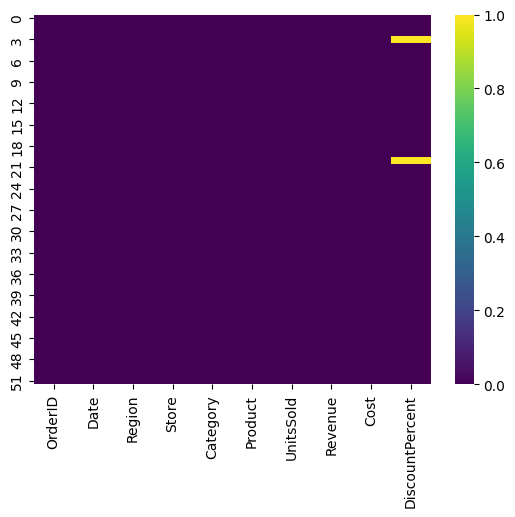

In [11]:
# check for missing values
missing_values = df.isnull()
sns.heatmap(missing_values,cmap='viridis')

In [12]:
df.describe()

,OrderID,DiscountPercent
count,52.000000,50.000000
mean,1024.865385,3.700000
std,14.691639,5.031533
min,1001.000000,0.000000
25%,1012.750000,0.000000
50%,1024.500000,0.000000
75%,1037.250000,5.000000
max,1050.000000,20.000000


In [13]:
df.isnull().sum()

OrderID            0
Date               0
Region             0
Store              0
Category           0
Product            0
UnitsSold          0
Revenue            0
Cost               0
DiscountPercent    2
dtype: int64

In [14]:
# Fixing Missing Discount values
df['DiscountPercent'] = df['DiscountPercent'].fillna(0)

In [15]:
# Imputing missing value with mean
df['Region'] = df['Region'].replace('Nan',None)
df['Region']=df['Region'].fillna('East')

In [16]:
df['Region'].unique()

array(['East', 'West', 'South'], dtype=object)

<Axes: >

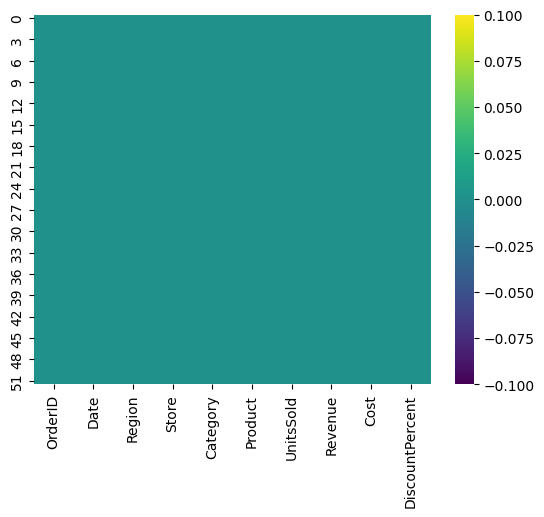

In [17]:
missing_values = df.isnull()
sns.heatmap(missing_values,cmap='viridis')

In [18]:
# Fix Numeric Data Types
df['UnitsSold'] = pd.to_numeric(df['UnitsSold'],errors='coerce')
df.isnull().sum()


OrderID            0
Date               0
Region             0
Store              0
Category           0
Product            0
UnitsSold          2
Revenue            0
Cost               0
DiscountPercent    0
dtype: int64

In [19]:
# df['Revenue']=df['Revenue'].replace(r'\$','',regex=True)
# To replace $ and comma ,
df['Revenue']=df['Revenue'].replace(r'[$,]','',regex=True)
df['Revenue']=pd.to_numeric(df['Revenue'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          52 non-null     int64  
 1   Date             52 non-null     object 
 2   Region           52 non-null     object 
 3   Store            52 non-null     object 
 4   Category         52 non-null     object 
 5   Product          52 non-null     object 
 6   UnitsSold        50 non-null     float64
 7   Revenue          52 non-null     float64
 8   Cost             52 non-null     object 
 9   DiscountPercent  52 non-null     float64
dtypes: float64(3), int64(1), object(6)
memory usage: 4.2+ KB


In [20]:
df['Cost']=df['Cost'].replace(r'[$,]','',regex=True)
# df['Cost']=df['Cost'].astype(float) # This code also works
df['Cost']=pd.to_numeric(df['Cost'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          52 non-null     int64  
 1   Date             52 non-null     object 
 2   Region           52 non-null     object 
 3   Store            52 non-null     object 
 4   Category         52 non-null     object 
 5   Product          52 non-null     object 
 6   UnitsSold        50 non-null     float64
 7   Revenue          52 non-null     float64
 8   Cost             52 non-null     float64
 9   DiscountPercent  52 non-null     float64
dtypes: float64(4), int64(1), object(5)
memory usage: 4.2+ KB


In [21]:
df

,OrderID,Date,Region,Store,Category,Product,UnitsSold,Revenue,Cost,DiscountPercent
0,1001,05/01/2026,East,Providence Cafe,Coffee,Latte,45.0,247.5,135.0,0.0
1,1002,2026-05-01,East,Providence Cafe,Food,Muffin,30.0,105.0,42.0,10.0
2,1003,2026/05/01,West,Seattle Central,Coffee,Cold Brew,52.0,286.0,140.0,5.0
3,1004,05-02-2026,South,Austin Beans,Tea,Chai Latte,28.0,126.0,56.0,0.0
4,1005,2026-05-02,West,Seattle Central,Food,Bagel,40.0,140.0,52.0,15.0
5,1006,2026-05-02,East,Providence Cafe,Coffee,Cappuccino,38.0,209.0,114.0,0.0
6,1007,2026-05-03,South,Austin Beans,Coffee,Americano,60.0,210.0,78.0,0.0
7,1008,2026-05-03,West,Seattle Central,Tea,Green Tea,25.0,87.5,30.0,0.0
8,1009,2026-05-03,East,Providence Cafe,Food,Croissant,18.0,81.0,36.0,20.0
9,1010,2026-05-04,South,Austin Beans,Food,Cookie,50.0,125.0,40.0,0.0


In [22]:
# Fix Date types
df['Date'] = pd.to_datetime(df['Date'],format='mixed',errors='coerce')
df.isnull().sum()

OrderID            0
Date               2
Region             0
Store              0
Category           0
Product            0
UnitsSold          2
Revenue            0
Cost               0
DiscountPercent    0
dtype: int64

In [23]:
# Missing values calculated at 3.8% of the total records, so dropped
# Drop values if missing data < 5%
df = df.dropna(subset=['Date','UnitsSold'])
df

,OrderID,Date,Region,Store,Category,Product,UnitsSold,Revenue,Cost,DiscountPercent
0,1001,2026-05-01,East,Providence Cafe,Coffee,Latte,45.0,247.5,135.0,0.0
1,1002,2026-05-01,East,Providence Cafe,Food,Muffin,30.0,105.0,42.0,10.0
2,1003,2026-05-01,West,Seattle Central,Coffee,Cold Brew,52.0,286.0,140.0,5.0
3,1004,2026-05-02,South,Austin Beans,Tea,Chai Latte,28.0,126.0,56.0,0.0
4,1005,2026-05-02,West,Seattle Central,Food,Bagel,40.0,140.0,52.0,15.0
5,1006,2026-05-02,East,Providence Cafe,Coffee,Cappuccino,38.0,209.0,114.0,0.0
6,1007,2026-05-03,South,Austin Beans,Coffee,Americano,60.0,210.0,78.0,0.0
7,1008,2026-05-03,West,Seattle Central,Tea,Green Tea,25.0,87.5,30.0,0.0
8,1009,2026-05-03,East,Providence Cafe,Food,Croissant,18.0,81.0,36.0,20.0
9,1010,2026-05-04,South,Austin Beans,Food,Cookie,50.0,125.0,40.0,0.0


In [24]:
df.isnull().sum()

OrderID            0
Date               0
Region             0
Store              0
Category           0
Product            0
UnitsSold          0
Revenue            0
Cost               0
DiscountPercent    0
dtype: int64

In [25]:
# Check and drop duplicates
print('Duplicates Before:',df.duplicated().sum())
df= df.drop_duplicates()
print('Duplicates After:',df.duplicated().sum())

Duplicates Before: 2
Duplicates After: 0


In [ ]:
# Feature creation - new calculated columns

df.loc[:,'Profit']=df['Revenue']-df['Cost']
df.loc[:,'Profit Margin'] = df['Profit']/df['Revenue']

In [27]:
df.head()

,OrderID,Date,Region,Store,Category,Product,UnitsSold,Revenue,Cost,DiscountPercent,Profit,Profit Margin
0,1001,2026-05-01,East,Providence Cafe,Coffee,Latte,45.0,247.5,135.0,0.0,112.5,0.454545
1,1002,2026-05-01,East,Providence Cafe,Food,Muffin,30.0,105.0,42.0,10.0,63.0,0.600000
2,1003,2026-05-01,West,Seattle Central,Coffee,Cold Brew,52.0,286.0,140.0,5.0,146.0,0.510490
3,1004,2026-05-02,South,Austin Beans,Tea,Chai Latte,28.0,126.0,56.0,0.0,70.0,0.555556
4,1005,2026-05-02,West,Seattle Central,Food,Bagel,40.0,140.0,52.0,15.0,88.0,0.628571


In [38]:
# Create the KPI
df.loc[:,'HighProfit'] = df['Profit'] > 100

In [29]:
df.head()

,OrderID,Date,Region,Store,Category,Product,UnitsSold,Revenue,Cost,DiscountPercent,Profit,Profit Margin,HighProfit
0,1001,2026-05-01,East,Providence Cafe,Coffee,Latte,45.0,247.5,135.0,0.0,112.5,0.454545,True
1,1002,2026-05-01,East,Providence Cafe,Food,Muffin,30.0,105.0,42.0,10.0,63.0,0.600000,False
2,1003,2026-05-01,West,Seattle Central,Coffee,Cold Brew,52.0,286.0,140.0,5.0,146.0,0.510490,True
3,1004,2026-05-02,South,Austin Beans,Tea,Chai Latte,28.0,126.0,56.0,0.0,70.0,0.555556,False
4,1005,2026-05-02,West,Seattle Central,Food,Bagel,40.0,140.0,52.0,15.0,88.0,0.628571,False


## Load

In [39]:
df.to_csv('data/cleaned_data.csv',index=False)

## Quick Analysis

In [40]:
print('Data Sample')
print(df.head())

Data Sample
   OrderID       Date Region            Store Category     Product  UnitsSold  \
0     1001 2026-05-01   East  Providence Cafe   Coffee       Latte       45.0   
1     1002 2026-05-01   East  Providence Cafe     Food      Muffin       30.0   
2     1003 2026-05-01   West  Seattle Central   Coffee   Cold Brew       52.0   
3     1004 2026-05-02  South     Austin Beans      Tea  Chai Latte       28.0   
4     1005 2026-05-02   West  Seattle Central     Food       Bagel       40.0   

   Revenue   Cost  DiscountPercent  Profit  Profit Margin  HighProfit  
0    247.5  135.0              0.0   112.5       0.454545        True  
1    105.0   42.0             10.0    63.0       0.600000       False  
2    286.0  140.0              5.0   146.0       0.510490        True  
3    126.0   56.0              0.0    70.0       0.555556       False  
4    140.0   52.0             15.0    88.0       0.628571       False  


In [41]:
print(' -- Profit by Store --')
print(df.groupby('Store')['Profit'].sum())

 -- Profit by Store --
Store
Austin Beans       1491.0
Providence Cafe    1571.0
Seattle Central    1163.5
Name: Profit, dtype: float64


In [42]:
print(' -- Profit by Category --')
print(df.groupby('Category')['Profit'].sum())

 -- Profit by Category --
Category
Coffee    2471.0
Food      1072.0
Tea        682.5
Name: Profit, dtype: float64


In [43]:
print(' -- Profit by Region --')
print(df.groupby('Region')['Profit'].sum())

 -- Profit by Region --
Region
East     1571.0
South    1491.0
West     1163.5
Name: Profit, dtype: float64


In [44]:
df['Region'].value_counts()

Region
East     18
West     14
South    14
Name: count, dtype: int64